# DAMICORE analyzes DAMICORE

DAMICORE was introduced as **Data-Mining of Code Repositories**: raw code can be treated as a collection of objects, compared with Normalized Compression Distance (NCD), arranged by Neighbor Joining, and partitioned into communities. This notebook applies that idea to the current implementation itself.

**Question:** what similarity structure does DamiCore recover from its own production Python modules?

This is an exploratory structural view, not an architecture-quality score. A shared cluster means that the chosen representation contains compressible similarity; it does not imply that modules should be merged or that package boundaries are wrong.

## Experimental contract

One object is one tracked Python **implementation module** from the five public DamiCore distributions.

- `packages/*/src/**/*.py` is considered only for the public DamiCore packages.
- `__init__.py` is excluded because it mainly declares package surfaces rather than implementation behavior.
- Tests, notebooks, documentation, generated files, and the private `synthetic_data` package are excluded.
- Files are analyzed as raw bytes. There is no tokenization, AST normalization, or language-specific feature extraction.
- The notebook uses the exact public pipeline: NCD → deterministic Neighbor Joining → FastGreedy clustering.
- A single worker keeps notebook execution simple and avoids process-pool behavior; it does not change the semantic result.

This notebook is self-contained: it does not assume it is running from inside a DamiCore checkout. It installs the published `damicore` package with `pip`, and clones the source tree it analyzes directly from the `delbem-research/damicore` GitHub repository into a temporary directory. The default source commit is pinned and printed so the saved analysis remains reproducible. It therefore needs network access to PyPI and GitHub, and `git` available on `PATH`.

Setting `DAMICORE_SELF_ANALYSIS_REPO` to an existing checkout skips the clone and analyzes that tree instead, which is how the repository's notebook test executes these cells with no network. A checkout supplied that way is read, never removed.

In [38]:
%pip install --quiet damicore

Note: you may need to restart the kernel to use updated packages.


In [71]:
import hashlib
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from damicore import ExecutionConfig, estimate, load_result, run
from IPython.display import display
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

REPO_URL = "https://github.com/delbem-research/damicore.git"
REPO_REF = os.environ.get("DAMICORE_SELF_ANALYSIS_REF", "main")

PUBLIC_PACKAGES = {
    "damicore",
    "damicore_normalizer",
    "damicore_distance",
    "damicore_tree_builder",
    "damicore_clusterizer",
}

package_colors = {
    "damicore": "tab:blue",
    "damicore_normalizer": "tab:orange",
    "damicore_distance": "tab:green",
    "damicore_tree_builder": "tab:purple",
    "damicore_clusterizer": "tab:pink",
}

existing = os.environ.get("DAMICORE_SELF_ANALYSIS_REPO")
cloned = not existing
if existing:
    repo_root = Path(existing).resolve()
    origin = f"local checkout: {repo_root}"
else:
    repo_root = Path(tempfile.mkdtemp(prefix="damicore-self-analysis-repo-"))
    subprocess.run(["git", "init", "--quiet", str(repo_root)], check=True)
    subprocess.run(["git", "remote", "add", "origin", REPO_URL], cwd=repo_root, check=True)
    subprocess.run(
        ["git", "fetch", "--quiet", "--depth", "1", "origin", REPO_REF],
        cwd=repo_root,
        check=True,
    )
    subprocess.run(["git", "checkout", "--quiet", "--detach", "FETCH_HEAD"], cwd=repo_root, check=True)
    origin = f"cloned repository ({REPO_URL}@{REPO_REF}): {repo_root}"

analyzed_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=repo_root, text=True
).strip()
commit_date = subprocess.check_output(
    ["git", "show", "-s", "--format=%cI", "HEAD"], cwd=repo_root, text=True
).strip()
commit_subject = subprocess.check_output(
    ["git", "show", "-s", "--format=%s", "HEAD"], cwd=repo_root, text=True
).strip()
if cloned and len(REPO_REF) == 40 and analyzed_commit != REPO_REF:
    raise RuntimeError(f"Expected source commit {REPO_REF}, got {analyzed_commit}.")

workspace_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
notebook_path = workspace_root / "notebooks/damicore_self_analysis.ipynb"
output_root = workspace_root / "notebooks/testes self analysis"
legacy_analysis_dir = output_root / analyzed_commit
readable_analysis_dir = output_root / f"{commit_date[:10]}_{analyzed_commit[:12]}"
analysis_dir = legacy_analysis_dir if legacy_analysis_dir.exists() else readable_analysis_dir
reused_analysis = analysis_dir.exists()

images_dir = analysis_dir / "images"
artifacts_dir = analysis_dir / "artifacts"
readme_path = analysis_dir / "README.md"
if reused_analysis:
    if not artifacts_dir.exists():
        raise FileNotFoundError(f"Incomplete saved analysis: {artifacts_dir}")
else:
    images_dir.mkdir(parents=True, exist_ok=False)
    artifacts_dir.mkdir(parents=True, exist_ok=False)
    shutil.copy2(notebook_path, analysis_dir / notebook_path.name)

readme_text = f"""# DAMICORE self-analysis\n\nThis folder contains the frozen self-analysis for one DAMICORE source commit.\n\n- Commit: `{analyzed_commit}`\n- Commit date: `{commit_date}`\n- Commit message: `{commit_subject}`\n- Source: `{REPO_URL}`\n- Requested ref: `{REPO_REF}`\n\n## Folder contents\n\n- `damicore_self_analysis.ipynb`: notebook used for this analysis.\n- `images/`: figures produced by the notebook.\n- `artifacts/`: DAMICORE distance matrix, tree, clusters, and report.\n\nThe result folder name is `{analysis_dir.name}`. New folders use `YYYY-MM-DD_short-commit`; older folders may use the full commit hash. Results are never overwritten by a different commit.\n"""
if not readme_path.exists():
    readme_path.write_text(readme_text, encoding="utf-8")

saved_figure_fingerprints = set()


def save_figure(figure):
    if reused_analysis:
        return
    figure.canvas.draw()
    pixels = np.asarray(figure.canvas.buffer_rgba())
    fingerprint = hashlib.sha256(pixels.tobytes()).hexdigest()
    if fingerprint in saved_figure_fingerprints:
        return
    saved_figure_fingerprints.add(fingerprint)
    filename = f"{len(saved_figure_fingerprints):02d}_figure.png"
    figure.savefig(images_dir / filename, dpi=180, bbox_inches="tight")


original_show = getattr(plt.show, "_damicore_original_show", plt.show)


def show_and_save(*args, **kwargs):
    save_figure(plt.gcf())
    return original_show(*args, **kwargs)


show_and_save._damicore_original_show = original_show
plt.show = show_and_save

tracked = subprocess.check_output(
    ["git", "ls-files", "packages"], cwd=repo_root, text=True
).splitlines()

relative_modules = []
for relative in tracked:
    path = Path(relative)
    if (
        len(path.parts) >= 5
        and path.parts[0] == "packages"
        and path.parts[1] in PUBLIC_PACKAGES
        and "src" in path.parts
        and path.suffix == ".py"
        and path.name != "__init__.py"
    ):
        relative_modules.append(path)

relative_modules.sort(key=lambda path: path.as_posix())
corpus = [repo_root / path for path in relative_modules]

if len(corpus) < 2:
    raise RuntimeError("Self-analysis requires at least two tracked production modules.")

corpus_summary = pd.DataFrame(
    {
        "package": [path.parts[1] for path in relative_modules],
        "module": [path.as_posix() for path in relative_modules],
        "bytes": [absolute.stat().st_size for absolute in corpus],
    }
)

print(origin)
print(f"analyzed commit: {analyzed_commit}")
print(f"commit date: {commit_date}")
print(f"analysis directory: {analysis_dir}")
print("reusing saved results" if reused_analysis else "creating new results")
display(
    corpus_summary.groupby("package", sort=True)
    .agg(modules=("module", "count"), bytes=("bytes", "sum"))
    .sort_index()
)

cloned repository (https://github.com/delbem-research/damicore.git@e66e0d453a901a12ac899e95ad3de70e44be8521): /tmp/damicore-self-analysis-repo-gm4f2enh
analyzed commit: e66e0d453a901a12ac899e95ad3de70e44be8521
commit date: 2026-08-30T18:05:44-03:00
analysis directory: /home/izaferrari/damicore/notebooks/testes self analysis/2026-08-30_e66e0d453a90
creating new results


,modules,bytes
package,,
damicore,9,99505
damicore_clusterizer,7,15683
damicore_distance,8,37976
damicore_normalizer,10,49162
damicore_tree_builder,7,20282


## Corpus balance

The amount of code contributed by each package affects how much evidence that package contributes to the analysis. These views separate object count from total source bytes: a package can have many small modules or a few large ones. They are descriptive context, not weights applied to NCD.


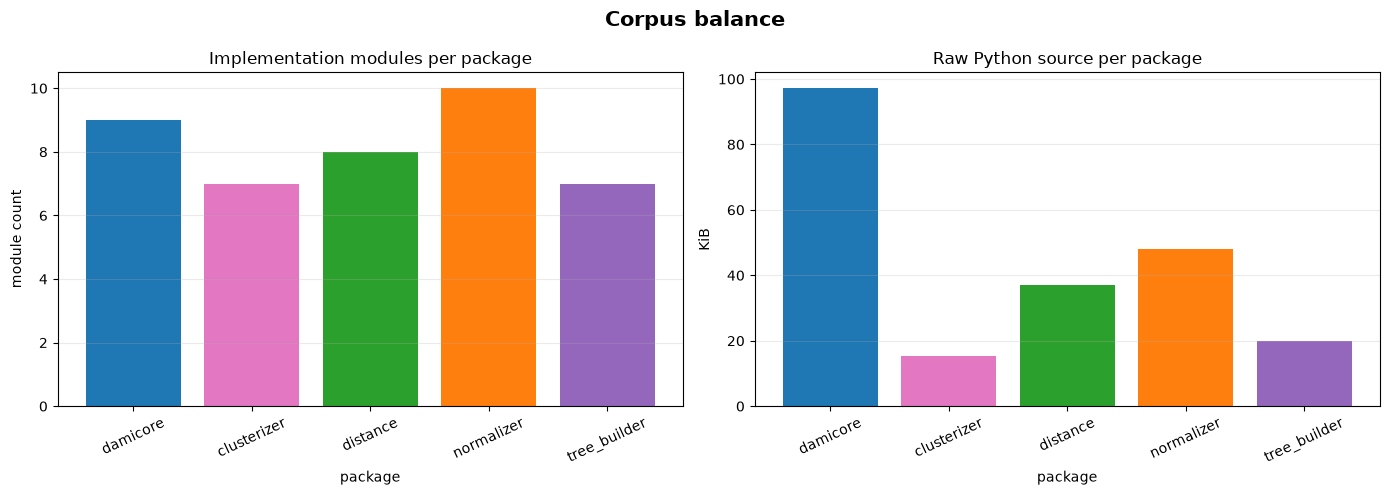

In [74]:
package_summary = (
    corpus_summary.groupby("package", sort=True)
    .agg(modules=("module", "count"), bytes=("bytes", "sum"))
    .sort_index()
)
package_names = [package.removeprefix("damicore_") for package in package_summary.index]
bar_colors = [package_colors[package] for package in package_summary.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(package_names, package_summary["modules"], color=bar_colors)
axes[0].set_title("Implementation modules per package")
axes[0].set_ylabel("module count")

axes[1].bar(package_names, package_summary["bytes"] / 1024, color=bar_colors)
axes[1].set_title("Raw Python source per package")
axes[1].set_ylabel("KiB")

for axis in axes:
    axis.set_xlabel("package")
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.25)

fig.suptitle("Corpus balance", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


## Pre-flight

DamiCore's cost is driven primarily by the number of objects: NCD is quadratic in object count and Neighbor Joining is cubic. `estimate()` performs the same input scan used by the run and decides whether the exact analysis fits the configured resource gates before any run artifacts are created.

In [72]:
execution = ExecutionConfig(workers=1)
preview = estimate(
    corpus,
    source_kind="files",
    execution=execution,
)

mib = 1024**2
display(
    pd.Series(
        {
            "objects": preview.object_count,
            "pairs": preview.pair_count,
            "input MiB": preview.input_size_bytes / mib,
            "matrix MiB": preview.matrix_bytes / mib,
            "estimated working memory MiB": preview.estimated_working_memory_bytes / mib,
            "required free disk MiB": preview.required_free_disk_bytes / mib,
            "within limits": preview.within_limits,
        },
        name="pre-flight",
    ).to_frame()
)

if not preview.within_limits:
    raise RuntimeError(f"Pre-flight rejected the run: {preview.violations}")

,pre-flight
objects,41
pairs,820
input MiB,0.212296
matrix MiB,0.012825
estimated working memory MiB,8.228882
required free disk MiB,1.767378
within limits,True


The run uses the same corpus and execution configuration that were pre-flighted. Each Git commit is analyzed under `notebooks/testes self analysis/YYYY-MM-DD_short-commit/`, with a README, notebook copy, generated images, and DAMICORE artifacts kept together. Existing older folders named with the full hash remain supported.

In [73]:
run_dir = artifacts_dir

if reused_analysis:
    result = load_result(run_dir)
else:
    result = run(
        corpus,
        source_kind="files",
        output_dir=run_dir,
        progress=False,
        execution=execution,
    )

display(
    pd.Series(
        {
            "status": result.report.status,
            "objects": result.report.object_count,
            "clusters": result.report.cluster_count,
            "modularity": result.report.modularity,
            "run directory": str(result.artifacts.run_dir),
            "images directory": str(images_dir),
            "saved notebook": str(analysis_dir / notebook_path.name),
            "reused existing results": reused_analysis,
        },
        name="result",
    ).to_frame()
)

,result
status,completed
objects,41
clusters,10
modularity,0.748232
run directory,/home/izaferrari/damicore/notebooks/testes sel...
images directory,/home/izaferrari/damicore/notebooks/testes sel...
saved notebook,/home/izaferrari/damicore/notebooks/testes sel...
reused existing results,False


## Distance heatmap

The matrix below shows the full pairwise NCD distance between every tracked module. Darker colors reflect smaller distances, so visually coherent blocks suggest modules with similar raw-byte structure; lighter cells mark more dissimilar modules. This is the quickest global view before reading the tree and the cluster summaries.


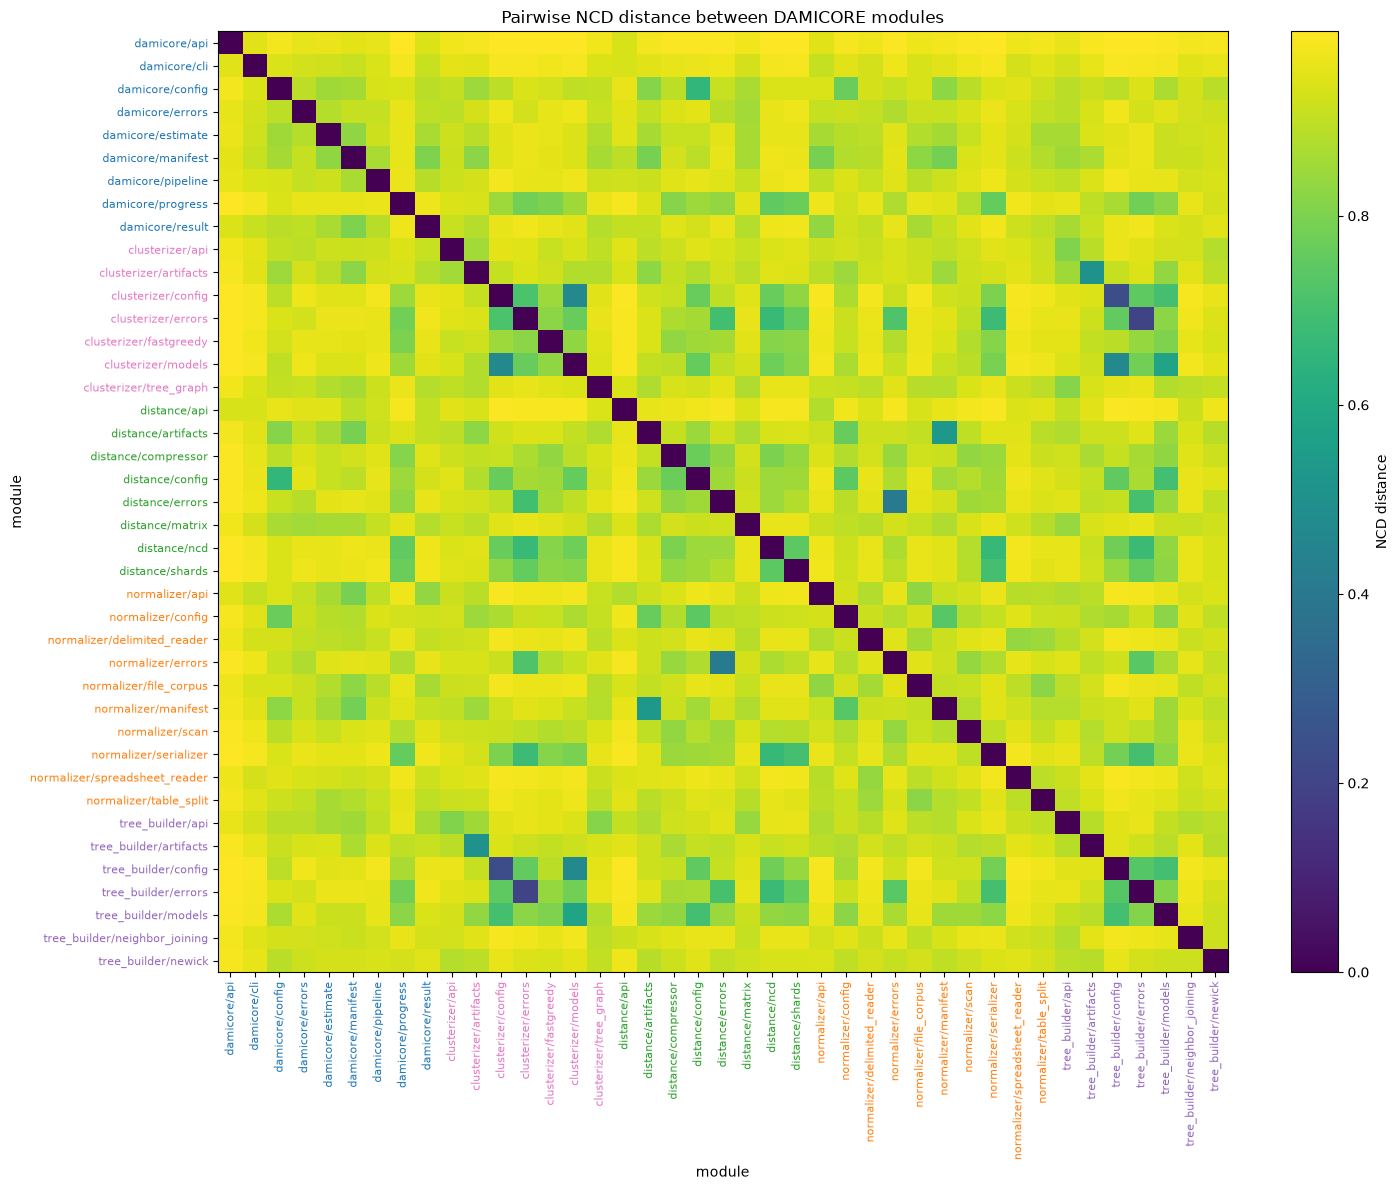

In [75]:
import matplotlib.pyplot as plt

package_colors = {
    "damicore": "tab:blue",
    "damicore_normalizer": "tab:orange",
    "damicore_distance": "tab:green",
    "damicore_tree_builder": "tab:purple",
    "damicore_clusterizer": "tab:pink",
}


def source_label(label):
    if label.startswith("file_"):
        try:
            index = int(label.removeprefix("file_")) - 1
        except ValueError:
            return label
        if 0 <= index < len(relative_modules):
            return relative_modules[index].as_posix()
    return label


def package_for_label(label):
    source = Path(source_label(label))
    if len(source.parts) >= 2 and source.parts[0] == "packages":
        return source.parts[1]
    return source.parts[0] if source.parts else label


def display_package(package):
    return package.removeprefix("damicore_")


def display_label(label):
    source = Path(source_label(label))
    if len(source.parts) >= 4 and source.parts[0] in PUBLIC_PACKAGES and source.parts[1] == "src":
        package = display_package(source.parts[0])
        module = Path(*source.parts[3:]).with_suffix("")
        return (Path(package) / module).as_posix()
    if len(source.parts) >= 5 and source.parts[0] == "packages" and source.parts[2] == "src":
        package = display_package(source.parts[1])
        module = Path(*source.parts[4:]).with_suffix("")
        return (Path(package) / module).as_posix()
    return source.with_suffix("").as_posix() or label


try:
    matrix = result.distance_matrix
except NameError:
    result = load_result(run_dir)
    matrix = result.distance_matrix

try:
    labels = list(matrix.labels)
    values = np.asarray(matrix[:, :])
except ValueError:
    result = load_result(run_dir)
    matrix = result.distance_matrix
    labels = list(matrix.labels)
    values = np.asarray(matrix[:, :])

ordered_labels = [display_label(label) for label in labels]
package_by_label = {
    display_label(label): package_for_label(label) for label in labels
}

distance_df = pd.DataFrame(values, index=ordered_labels, columns=ordered_labels)

fig, ax = plt.subplots(figsize=(15, 12))
image = ax.imshow(distance_df.to_numpy(), cmap="viridis", aspect="auto")
ax.set_title("Pairwise NCD distance between DAMICORE modules")
ax.set_xlabel("module")
ax.set_ylabel("module")
ax.set_xticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, rotation=90)
ax.set_yticks(range(len(ordered_labels)))
ax.set_yticklabels(ordered_labels)

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    label_name = tick.get_text()
    color = package_colors.get(package_by_label.get(label_name, "damicore"), "#444444")
    tick.set_color(color)
    tick.set_fontsize(8)

fig.colorbar(image, ax=ax, label="NCD distance")
fig.tight_layout()
plt.show()


## Tree visualization

The tree below is the geometric representation of the structure discovered by DAMICORE. Each leaf is a Python module; modules that join closer together have lower NCD distance. Colors indicate the source package, not the cluster: this makes it possible to compare the discovered structure with the known architecture.

Labels are abbreviated in both the heatmap and tree to keep them readable. The `membership` table above preserves the complete paths.

,cluster,label,source_label,display_label
0,0,damicore/src/damicore/api.py,damicore/src/damicore/api.py,damicore/api
1,0,damicore/src/damicore/cli.py,damicore/src/damicore/cli.py,damicore/cli
2,0,damicore_distance/src/damicore_distance/api.py,damicore_distance/src/damicore_distance/api.py,distance/api
3,1,damicore/src/damicore/config.py,damicore/src/damicore/config.py,damicore/config
4,1,damicore_distance/src/damicore_distance/artifa...,damicore_distance/src/damicore_distance/artifa...,distance/artifacts
5,1,damicore_distance/src/damicore_distance/config.py,damicore_distance/src/damicore_distance/config.py,distance/config
6,1,damicore_normalizer/src/damicore_normalizer/co...,damicore_normalizer/src/damicore_normalizer/co...,normalizer/config
7,1,damicore_normalizer/src/damicore_normalizer/ma...,damicore_normalizer/src/damicore_normalizer/ma...,normalizer/manifest
8,2,damicore/src/damicore/errors.py,damicore/src/damicore/errors.py,damicore/errors
9,2,damicore/src/damicore/pipeline.py,damicore/src/damicore/pipeline.py,damicore/pipeline


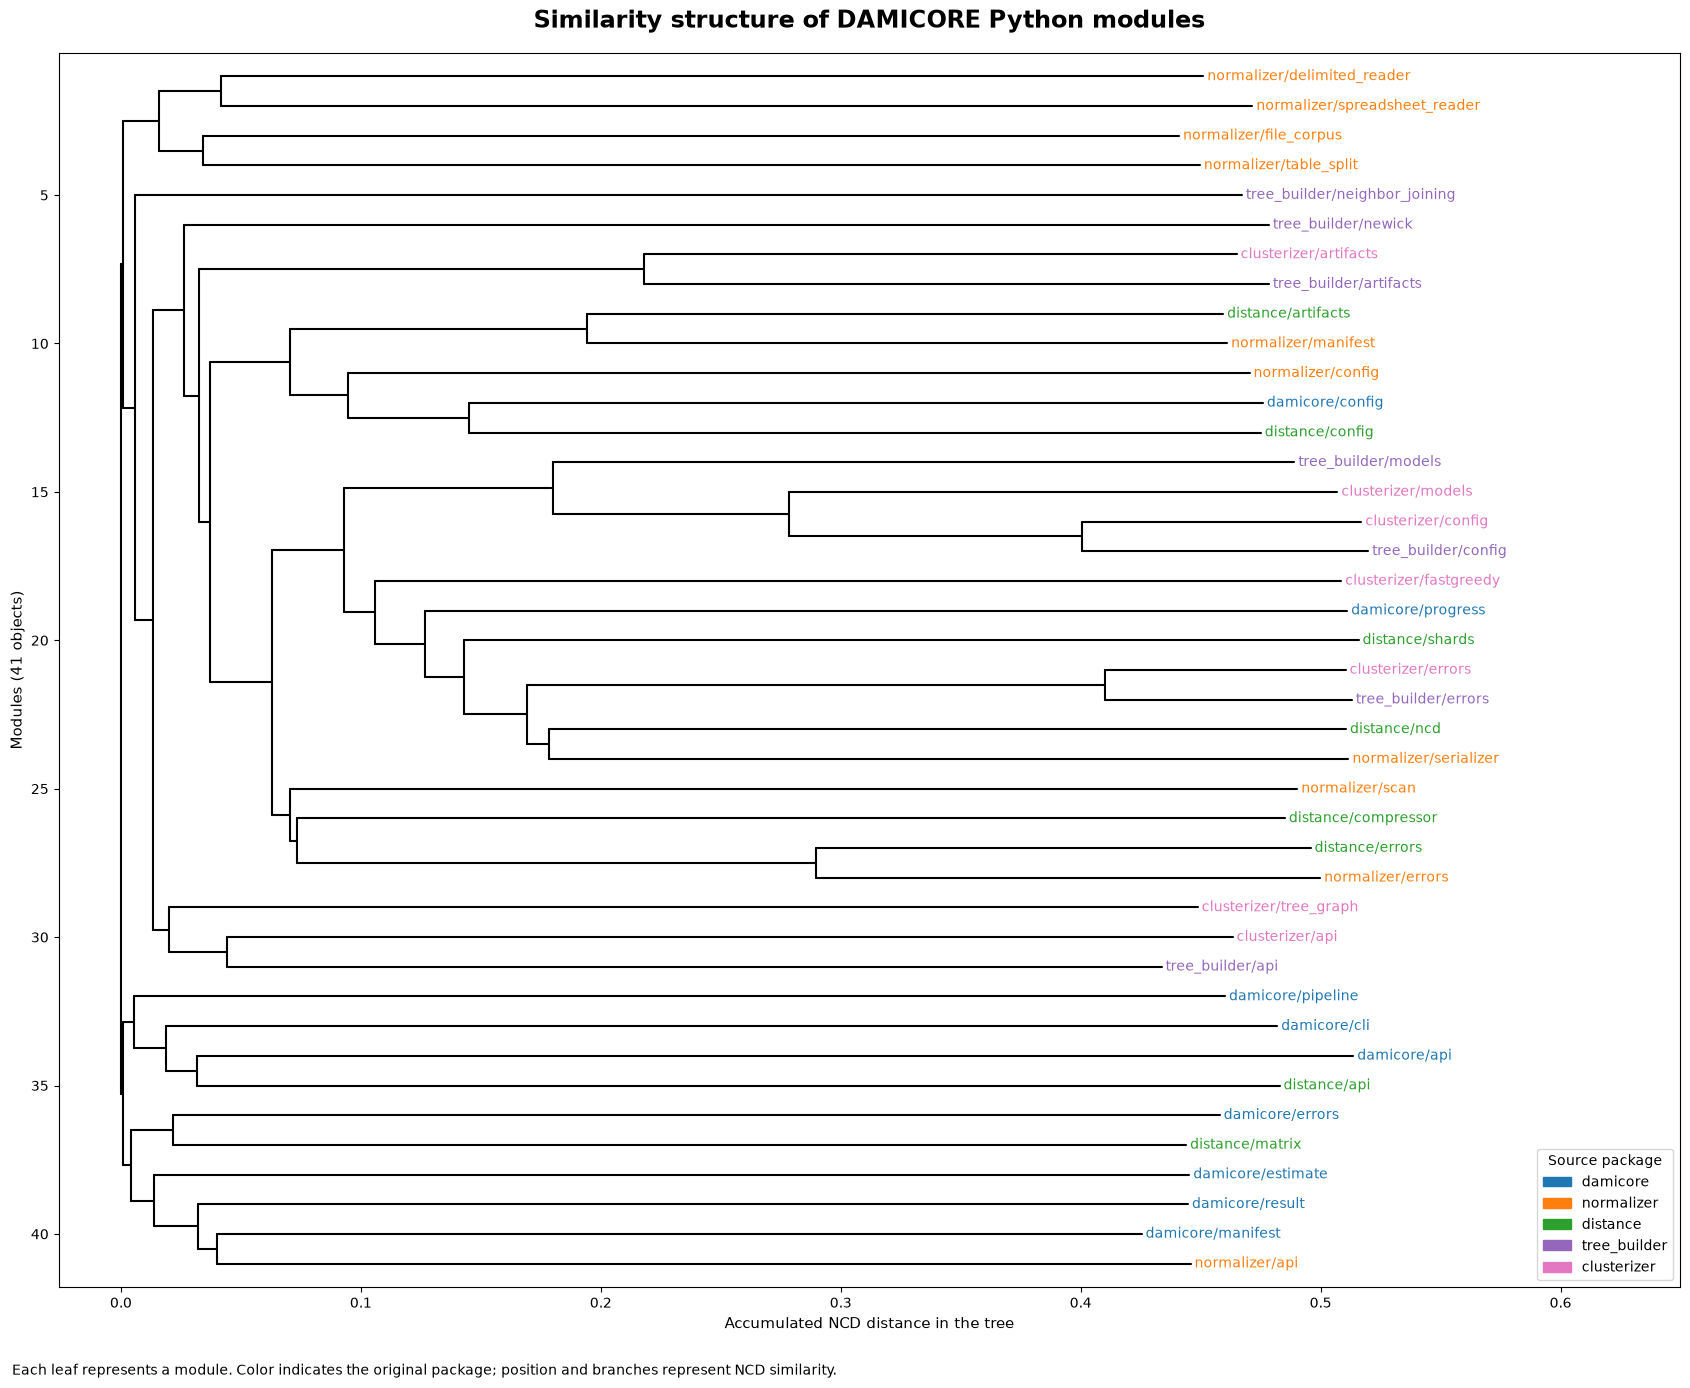

In [76]:
from Bio import Phylo
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

package_colors = {
    "damicore": "tab:blue",
    "damicore_normalizer": "tab:orange",
    "damicore_distance": "tab:green",
    "damicore_tree_builder": "tab:purple",
    "damicore_clusterizer": "tab:pink",
}


def source_label(label):
    if label.startswith("file_"):
        try:
            index = int(label.removeprefix("file_")) - 1
        except ValueError:
            return label
        if 0 <= index < len(relative_modules):
            return relative_modules[index].as_posix()
    return label


def package_for_label(label):
    source = Path(source_label(label))
    if len(source.parts) >= 2 and source.parts[0] == "packages":
        return source.parts[1]
    return source.parts[0] if source.parts else label


def display_package(package):
    return package.removeprefix("damicore_")


def display_label(label):
    source = Path(source_label(label))
    if len(source.parts) >= 4 and source.parts[0] in PUBLIC_PACKAGES and source.parts[1] == "src":
        package = display_package(source.parts[0])
        module = Path(*source.parts[3:]).with_suffix("")
        return (Path(package) / module).as_posix()
    if len(source.parts) >= 5 and source.parts[0] == "packages" and source.parts[2] == "src":
        package = display_package(source.parts[1])
        module = Path(*source.parts[4:]).with_suffix("")
        return (Path(package) / module).as_posix()
    return source.with_suffix("").as_posix() or label

# Rebuild the display table from the verified run result so the figure is self-contained
# even when this cell is executed after a fresh kernel reset.
membership = result.membership.copy()
membership["source_label"] = membership["label"].map(source_label)
membership["display_label"] = membership["source_label"].map(display_label)

display(
    membership[["cluster", "label", "source_label", "display_label"]]
    .sort_values(["cluster", "source_label"])
    .reset_index(drop=True)
)

tree_path = result.artifacts.run_dir / "tree.nwk"
tree = Phylo.read(str(tree_path), "newick")

label_colors = {}
for terminal in tree.get_terminals():
    if terminal.name is None:
        continue
    package = package_for_label(terminal.name)
    label_colors[display_label(terminal.name)] = package_colors.get(package, "#444444")

fig_height = max(11, 0.34 * len(tree.get_terminals()))
fig, axes = plt.subplots(figsize=(17, fig_height))
Phylo.draw(
    tree,
    axes=axes,
    label_func=lambda clade: display_label(clade.name) if clade.is_terminal() else None,
    label_colors=label_colors,
    do_show=False,
)
axes.set_title(
    "Similarity structure of DAMICORE Python modules",
    fontsize=17,
    fontweight="bold",
    pad=18,
)
axes.set_xlabel("Accumulated NCD distance in the tree", fontsize=11)
axes.set_ylabel(f"Modules ({len(tree.get_terminals())} objects)", fontsize=11)
axes.legend(
    handles=[
        Patch(facecolor=color, edgecolor=color, label=display_package(package))
        for package, color in package_colors.items()
    ],
    title="Source package",
    loc="lower right",
    frameon=True,
)
fig.text(
    0.01,
    0.01,
    "Each leaf represents a module. Color indicates the original package; position and branches represent NCD similarity.",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


## Cluster-ordered distance map

The first heatmap preserves package order, which makes package-level blocks easy to inspect. Reordering the same exact matrix by discovered cluster tests a different question: whether FastGreedy communities occupy compact regions in the underlying distances. White separators mark cluster boundaries, while label colors still show package ownership.


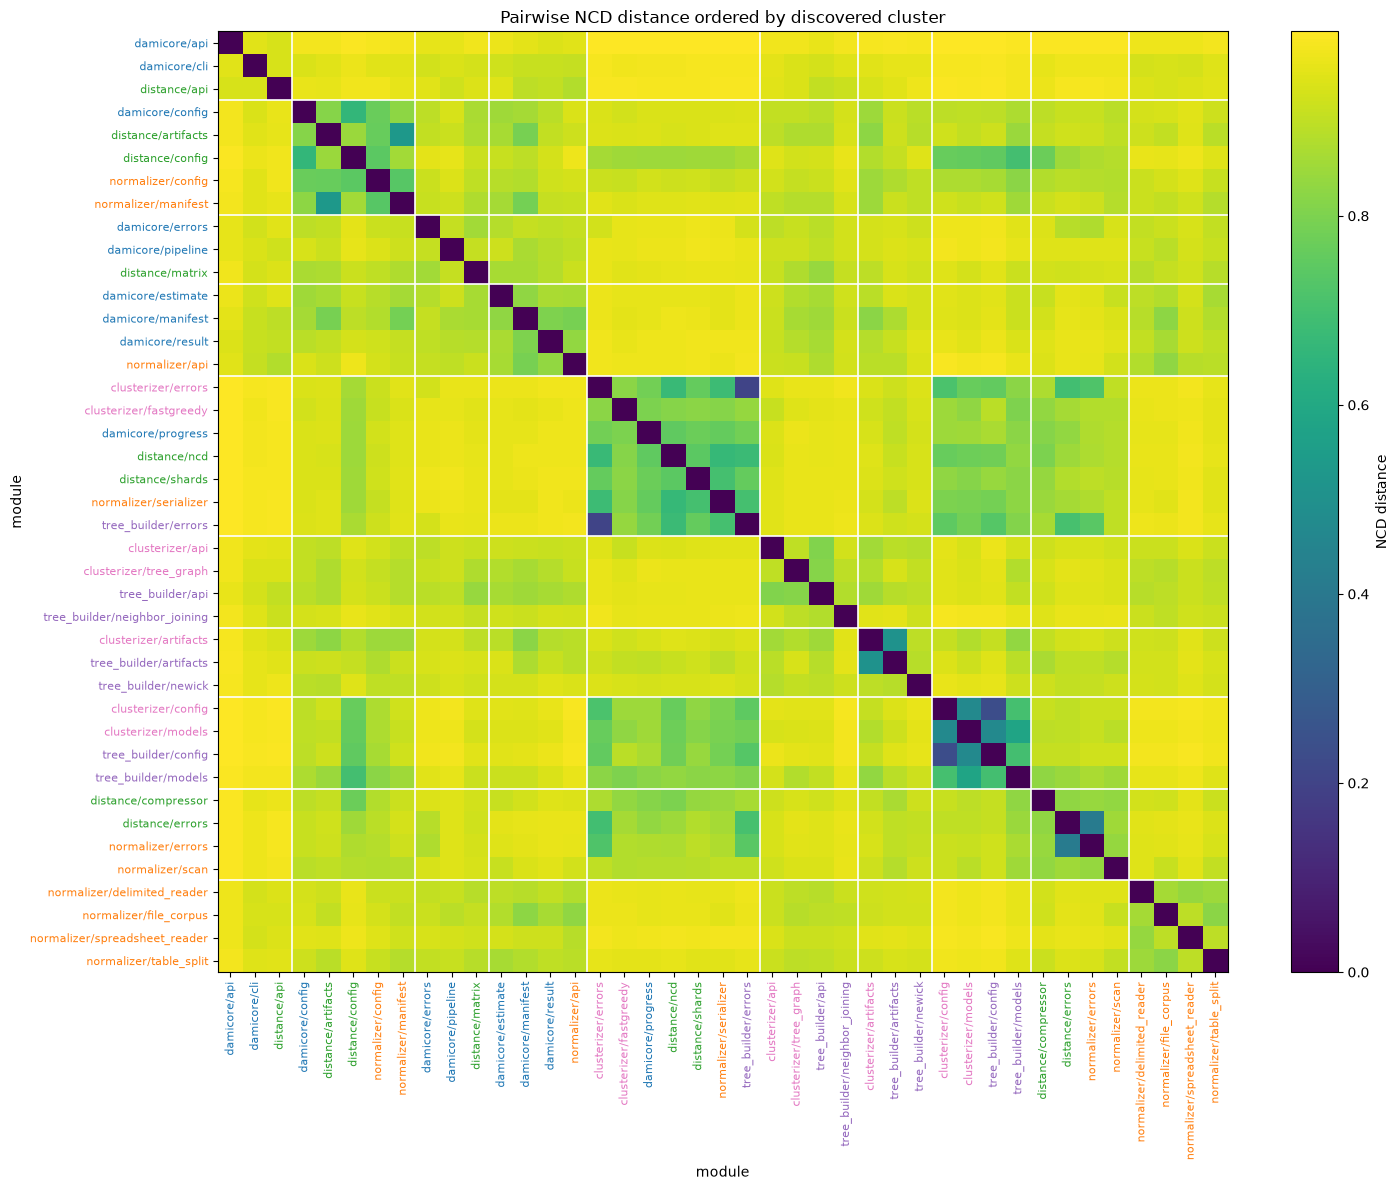

In [77]:
cluster_for_label = membership.set_index("label")["cluster"].to_dict()
cluster_order = sorted(
    range(len(labels)),
    key=lambda index: (cluster_for_label[labels[index]], display_label(labels[index])),
)
clustered_values = values[np.ix_(cluster_order, cluster_order)]
clustered_labels = [display_label(labels[index]) for index in cluster_order]
clustered_ids = [cluster_for_label[labels[index]] for index in cluster_order]

fig, ax = plt.subplots(figsize=(15, 12))
image = ax.imshow(clustered_values, cmap="viridis", aspect="auto")
ax.set_title("Pairwise NCD distance ordered by discovered cluster")
ax.set_xlabel("module")
ax.set_ylabel("module")
ax.set_xticks(range(len(clustered_labels)))
ax.set_xticklabels(clustered_labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(clustered_labels)))
ax.set_yticklabels(clustered_labels, fontsize=8)

for tick, index in zip(ax.get_xticklabels(), cluster_order):
    tick.set_color(package_colors.get(package_for_label(labels[index]), "#444444"))
for tick, index in zip(ax.get_yticklabels(), cluster_order):
    tick.set_color(package_colors.get(package_for_label(labels[index]), "#444444"))

# Draw each boundary once between adjacent cluster blocks.
for position in range(1, len(clustered_ids)):
    if clustered_ids[position] != clustered_ids[position - 1]:
        boundary = position - 0.5
        ax.axhline(boundary, color="white", linewidth=1.2)
        ax.axvline(boundary, color="white", linewidth=1.2)

fig.colorbar(image, ax=ax, label="NCD distance")
fig.tight_layout()
plt.show()


## Do discovered communities resemble package boundaries?

Package ownership is known independently from the clustering, so it is a useful external label for reading the result. Agreement is interesting, but disagreement is not automatically a defect: DamiCore measures compressible similarity in raw module bytes, while package boundaries encode software responsibilities.

In [78]:
membership = result.membership.copy()
membership["package"] = membership["label"].map(lambda label: Path(label).parts[0])

display(
    membership[["cluster", "package", "label"]]
    .sort_values(["cluster", "package", "label"])
    .reset_index(drop=True)
)

display(
    pd.crosstab(
        membership["cluster"],
        membership["package"],
        rownames=["cluster"],
        colnames=["package"],
    )
)

,cluster,package,label
0,0,damicore,damicore/src/damicore/api.py
1,0,damicore,damicore/src/damicore/cli.py
2,0,damicore_distance,damicore_distance/src/damicore_distance/api.py
3,1,damicore,damicore/src/damicore/config.py
4,1,damicore_distance,damicore_distance/src/damicore_distance/artifa...
5,1,damicore_distance,damicore_distance/src/damicore_distance/config.py
6,1,damicore_normalizer,damicore_normalizer/src/damicore_normalizer/co...
7,1,damicore_normalizer,damicore_normalizer/src/damicore_normalizer/ma...
8,2,damicore,damicore/src/damicore/errors.py
9,2,damicore,damicore/src/damicore/pipeline.py


package,damicore,damicore_clusterizer,damicore_distance,damicore_normalizer,damicore_tree_builder
cluster,,,,,
0,2,0,1,0,0
1,1,0,2,2,0
2,2,0,1,0,0
3,3,0,0,1,0
4,1,2,2,1,1
5,0,2,0,0,2
6,0,1,0,0,2
7,0,2,0,0,2
8,0,0,2,2,0


## Cluster composition

Raw counts reveal cluster size; proportions reveal purity independently of size. Read together, the panels show whether a community is dominated by one package or connects responsibilities implemented in several packages. Mixed clusters are structural observations, not architecture violations.


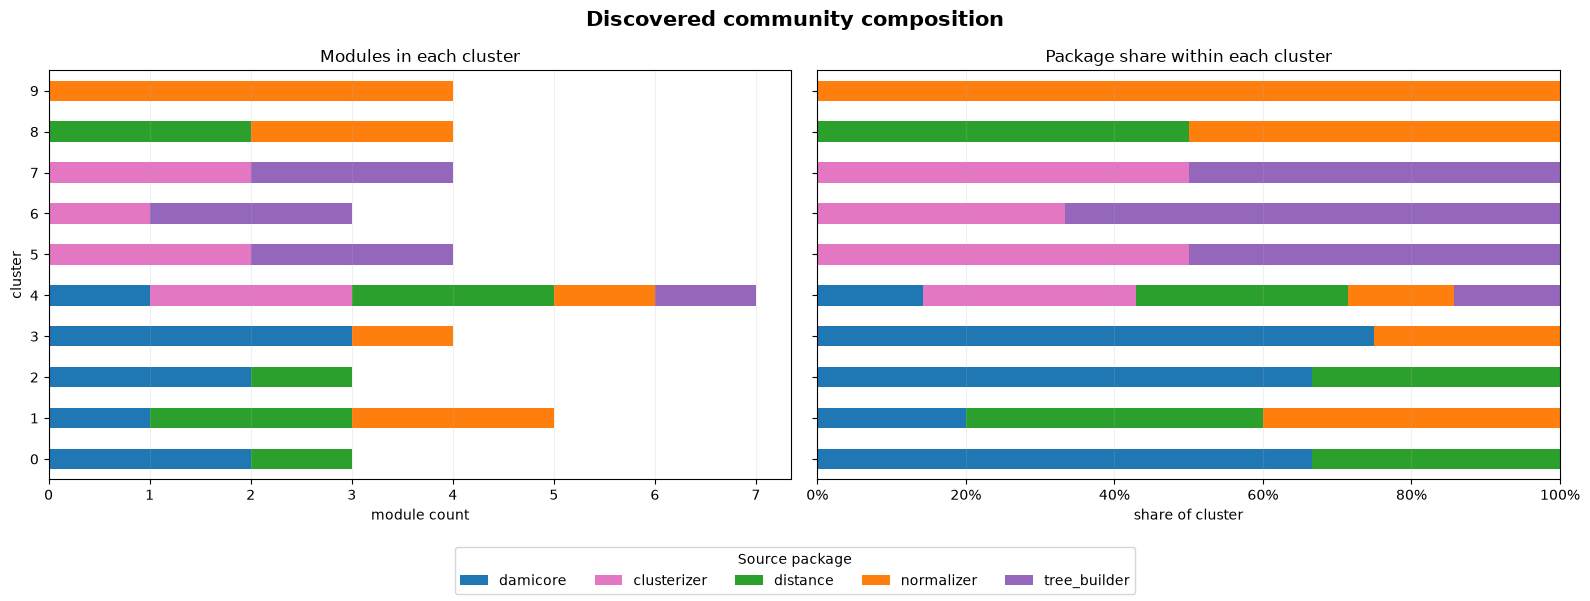

In [79]:
cluster_package_counts = pd.crosstab(membership["cluster"], membership["package"])
cluster_package_counts = cluster_package_counts.reindex(columns=sorted(PUBLIC_PACKAGES), fill_value=0)
cluster_package_share = cluster_package_counts.div(cluster_package_counts.sum(axis=1), axis=0)
colors = [package_colors[package] for package in cluster_package_counts.columns]
legend_labels = [display_package(package) for package in cluster_package_counts.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
cluster_package_counts.plot.barh(stacked=True, color=colors, ax=axes[0], legend=False)
axes[0].set_title("Modules in each cluster")
axes[0].set_xlabel("module count")
axes[0].set_ylabel("cluster")
cluster_package_share.plot.barh(stacked=True, color=colors, ax=axes[1], legend=False)
axes[1].set_title("Package share within each cluster")
axes[1].set_xlabel("share of cluster")
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))

for axis in axes:
    axis.grid(axis="x", alpha=0.2)

fig.legend(legend_labels, title="Source package", loc="lower center", ncol=5)
fig.suptitle("Discovered community composition", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()


## Which modules are closest?

Clusters summarize the global structure. The smallest off-diagonal NCD values expose the strongest pairwise similarities directly. The package-level table then compresses the same pairwise evidence into mean distances within and across packages.

In [48]:
matrix = result.distance_matrix
labels = list(matrix.labels)
packages = [Path(label).parts[0] for label in labels]

pair_rows = []
for left in range(len(labels)):
    for right in range(left + 1, len(labels)):
        package_a, package_b = sorted((packages[left], packages[right]))
        pair_rows.append(
            {
                "left": labels[left],
                "right": labels[right],
                "package_a": package_a,
                "package_b": package_b,
                "ncd": float(matrix[left, right]),
            }
        )

pairs = pd.DataFrame(pair_rows).sort_values("ncd", ignore_index=True)

display(pairs[["left", "right", "ncd"]].head(15))

package_distance = pd.DataFrame(
    np.nan,
    index=sorted(PUBLIC_PACKAGES),
    columns=sorted(PUBLIC_PACKAGES),
)

for (package_a, package_b), group in pairs.groupby(["package_a", "package_b"]):
    mean_distance = group["ncd"].mean()
    package_distance.loc[package_a, package_b] = mean_distance
    package_distance.loc[package_b, package_a] = mean_distance

display(package_distance.round(3))

,left,right,ncd
0,damicore_clusterizer/src/damicore_clusterizer/...,damicore_tree_builder/src/damicore_tree_builde...,0.203209
1,damicore_clusterizer/src/damicore_clusterizer/...,damicore_tree_builder/src/damicore_tree_builde...,0.235669
2,damicore_distance/src/damicore_distance/errors.py,damicore_normalizer/src/damicore_normalizer/er...,0.415929
3,damicore_clusterizer/src/damicore_clusterizer/...,damicore_clusterizer/src/damicore_clusterizer/...,0.468182
4,damicore_clusterizer/src/damicore_clusterizer/...,damicore_tree_builder/src/damicore_tree_builde...,0.468182
5,damicore_clusterizer/src/damicore_clusterizer/...,damicore_tree_builder/src/damicore_tree_builde...,0.507806
6,damicore_clusterizer/src/damicore_clusterizer/...,damicore_tree_builder/src/damicore_tree_builde...,0.582902
7,damicore/src/damicore/config.py,damicore_distance/src/damicore_distance/config.py,0.660670
8,damicore_distance/src/damicore_distance/ncd.py,damicore_normalizer/src/damicore_normalizer/se...,0.665094
9,damicore_clusterizer/src/damicore_clusterizer/...,damicore_distance/src/damicore_distance/ncd.py,0.673077


,damicore,damicore_clusterizer,damicore_distance,damicore_normalizer,damicore_tree_builder
damicore,0.922,0.933,0.923,0.930,0.933
damicore_clusterizer,0.933,0.871,0.892,0.931,0.849
damicore_distance,0.923,0.892,0.899,0.920,0.897
damicore_normalizer,0.930,0.931,0.920,0.921,0.930
damicore_tree_builder,0.933,0.849,0.897,0.930,0.903


## Within-package and cross-package distances

If package boundaries align with raw-code similarity, within-package pairs should tend to have lower NCD than cross-package pairs. The histogram compares the full distributions rather than only their means, while the annotated heatmap identifies which package pairs are especially close or far apart.


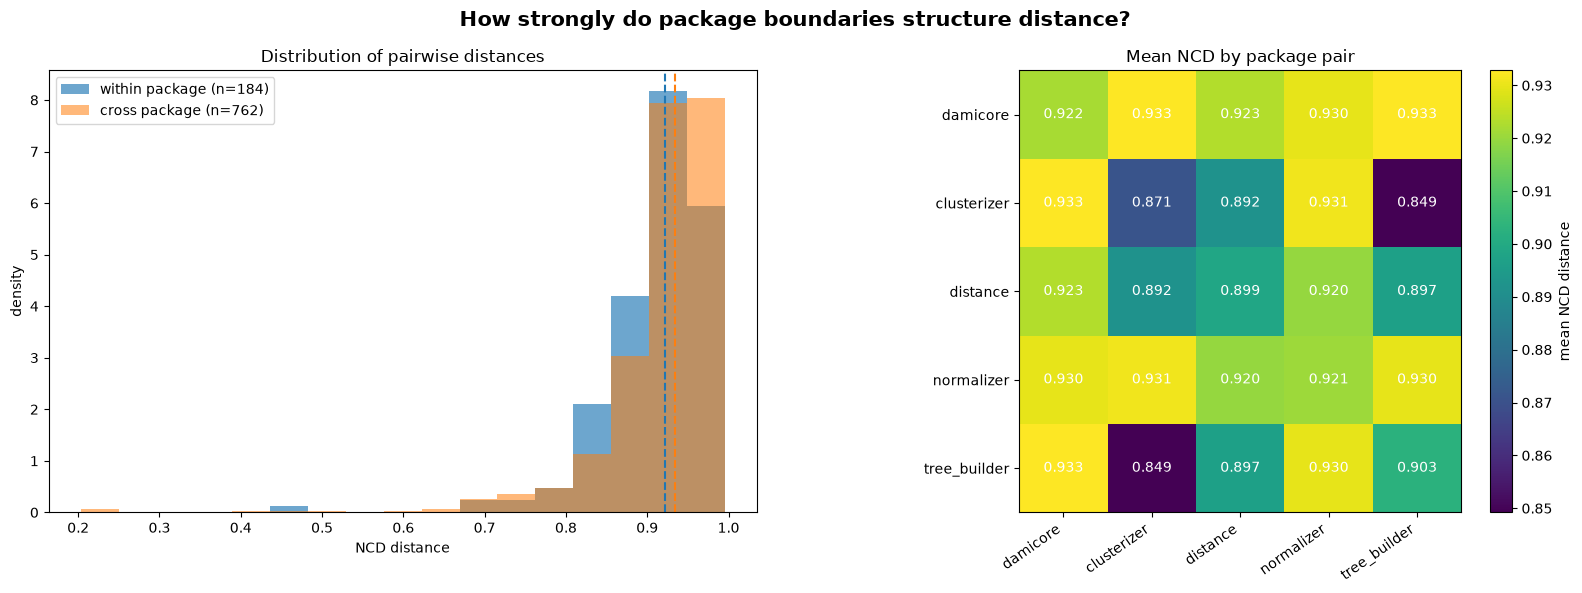

In [80]:
within_package = pairs.loc[pairs["package_a"] == pairs["package_b"], "ncd"]
cross_package = pairs.loc[pairs["package_a"] != pairs["package_b"], "ncd"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bins = np.linspace(pairs["ncd"].min(), pairs["ncd"].max(), 18)
axes[0].hist(
    within_package, bins=bins, density=True, alpha=0.65,
    label=f"within package (n={len(within_package)})", color="tab:blue",
)
axes[0].hist(
    cross_package, bins=bins, density=True, alpha=0.55,
    label=f"cross package (n={len(cross_package)})", color="tab:orange",
)
axes[0].axvline(within_package.median(), color="tab:blue", linestyle="--", linewidth=1.5)
axes[0].axvline(cross_package.median(), color="tab:orange", linestyle="--", linewidth=1.5)
axes[0].set_title("Distribution of pairwise distances")
axes[0].set_xlabel("NCD distance")
axes[0].set_ylabel("density")
axes[0].legend()

image = axes[1].imshow(package_distance.to_numpy(dtype=float), cmap="viridis", aspect="equal")
short_packages = [display_package(package) for package in package_distance.index]
axes[1].set_xticks(range(len(short_packages)), short_packages, rotation=35, ha="right")
axes[1].set_yticks(range(len(short_packages)), short_packages)
axes[1].set_title("Mean NCD by package pair")
for row in range(len(short_packages)):
    for column in range(len(short_packages)):
        value = package_distance.iloc[row, column]
        axes[1].text(column, row, f"{value:.3f}", ha="center", va="center", color="white")
fig.colorbar(image, ax=axes[1], label="mean NCD distance", fraction=0.046, pad=0.04)
fig.suptitle("How strongly do package boundaries structure distance?", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


## Nearest-neighbor bridges

Every bar records a module's closest peer. Green bars stay within the same package; red bars cross a package boundary. This avoids focusing only on the globally closest pairs and exposes both strong bridges and comparatively isolated modules across the complete corpus.


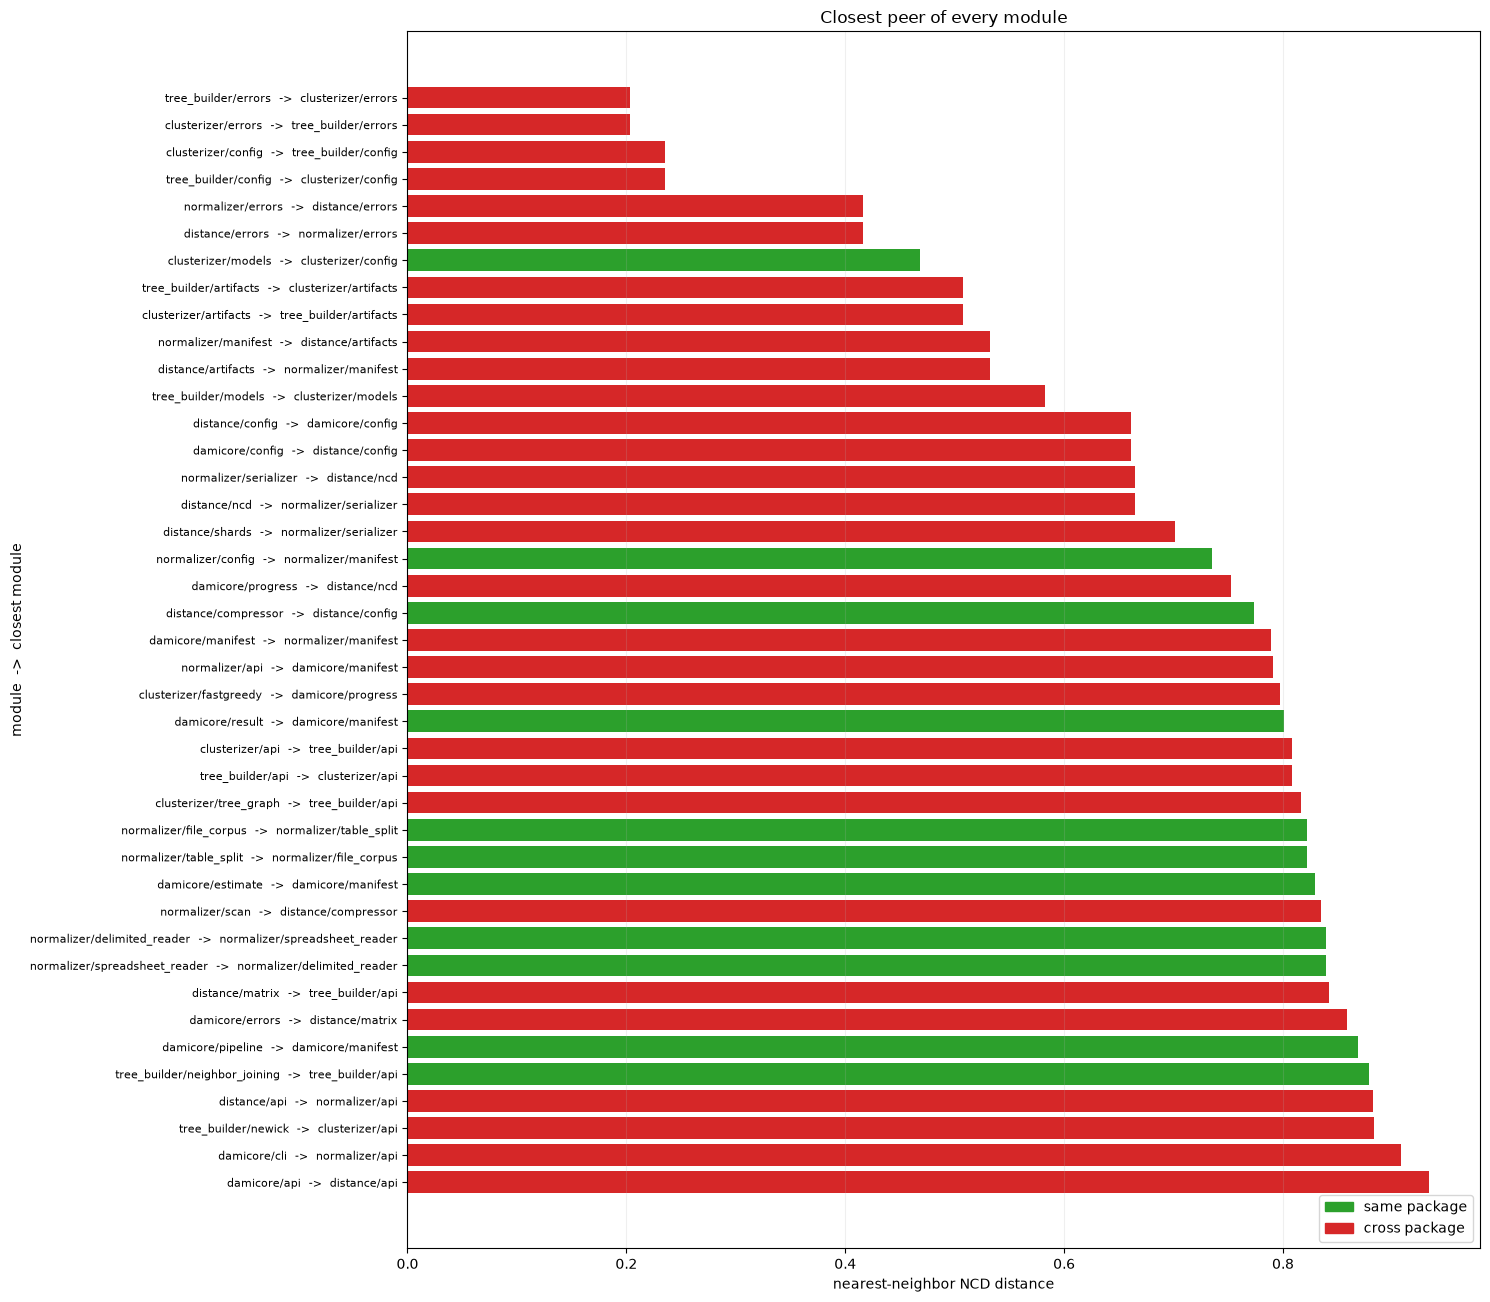

In [81]:
nearest_rows = []
for index, label in enumerate(labels):
    distances = values[index].astype(float).copy()
    distances[index] = np.inf
    neighbor_index = int(np.argmin(distances))
    neighbor = labels[neighbor_index]
    package = package_for_label(label)
    neighbor_package = package_for_label(neighbor)
    nearest_rows.append(
        {
            "module": display_label(label),
            "neighbor": display_label(neighbor),
            "ncd": float(distances[neighbor_index]),
            "same_package": package == neighbor_package,
        }
    )

nearest = pd.DataFrame(nearest_rows).sort_values("ncd", ascending=False, ignore_index=True)
bar_labels = [f"{row.module}  ->  {row.neighbor}" for row in nearest.itertuples()]
bar_colors = nearest["same_package"].map({True: "tab:green", False: "tab:red"})

fig_height = max(10, 0.32 * len(nearest))
fig, ax = plt.subplots(figsize=(15, fig_height))
ax.barh(range(len(nearest)), nearest["ncd"], color=bar_colors)
ax.set_yticks(range(len(nearest)), bar_labels, fontsize=8)
ax.set_xlabel("nearest-neighbor NCD distance")
ax.set_ylabel("module  ->  closest module")
ax.set_title("Closest peer of every module")
ax.grid(axis="x", alpha=0.2)
ax.legend(
    handles=[
        Patch(color="tab:green", label="same package"),
        Patch(color="tab:red", label="cross package"),
    ],
    loc="lower right",
)
fig.tight_layout()
plt.show()


## Module size and average distance

NCD normalizes compressed size, but finite compressor overhead can still make very small files behave differently. Plotting source size against each module's mean distance is a diagnostic for that possible representation effect. A visible association would motivate a controlled follow-up; it would not by itself prove size bias or explain a cluster.


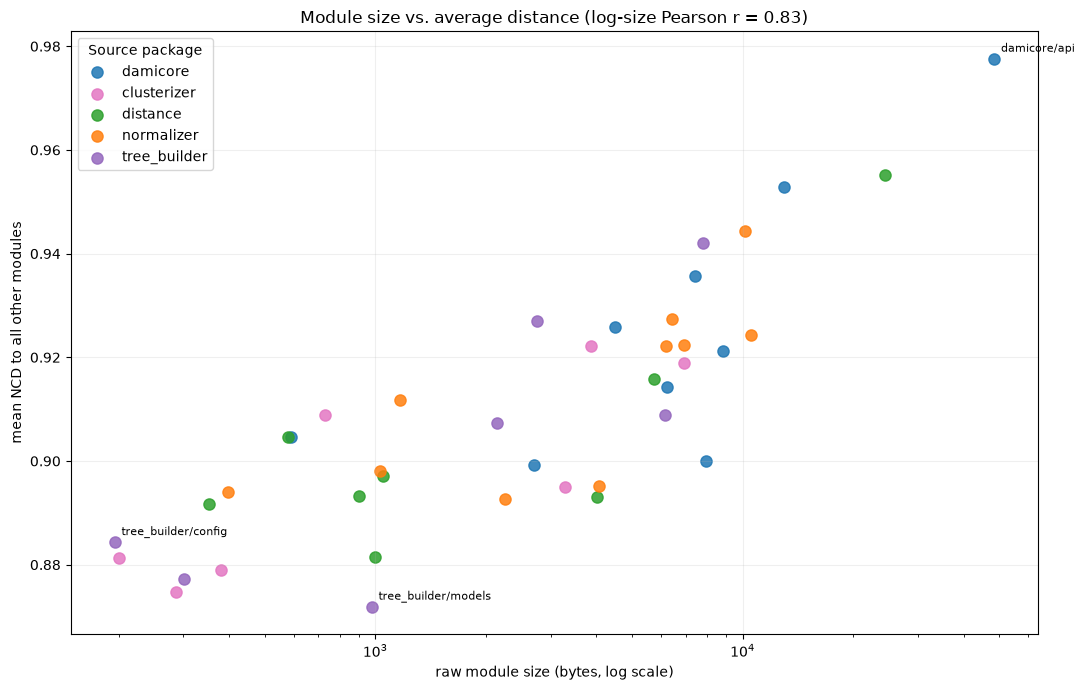

In [82]:
bytes_by_label = {
    Path(module).relative_to("packages").as_posix(): byte_count
    for module, byte_count in corpus_summary[["module", "bytes"]].itertuples(index=False)
}
mean_distance = (values.sum(axis=1) - np.diag(values)) / (len(labels) - 1)
module_bytes = np.array([bytes_by_label[label] for label in labels], dtype=float)
log_size_correlation = float(np.corrcoef(np.log10(module_bytes), mean_distance)[0, 1])

fig, ax = plt.subplots(figsize=(11, 7))
for package in sorted(PUBLIC_PACKAGES):
    indices = [index for index, label in enumerate(labels) if package_for_label(label) == package]
    ax.scatter(
        module_bytes[indices], mean_distance[indices], color=package_colors[package],
        label=display_package(package), s=65, alpha=0.85,
    )

# Label only extrema to keep the diagnostic readable.
extrema = {
    int(np.argmin(module_bytes)), int(np.argmax(module_bytes)),
    int(np.argmin(mean_distance)), int(np.argmax(mean_distance)),
}
for index in sorted(extrema):
    ax.annotate(
        display_label(labels[index]), (module_bytes[index], mean_distance[index]),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("raw module size (bytes, log scale)")
ax.set_ylabel("mean NCD to all other modules")
ax.set_title(f"Module size vs. average distance (log-size Pearson r = {log_size_correlation:.2f})")
ax.grid(alpha=0.2)
ax.legend(title="Source package")
fig.tight_layout()
plt.show()


## Temporal analysis across Git history

This optional section analyzes several DAMICORE commits in isolated temporary worktrees. It does not change the current checkout, does not write results into the repository, and continues when an older commit cannot run. Set `TEMPORAL_COUNT` or `TEMPORAL_REFS` in the next cell to choose the history window.

In [84]:
import sys

In [86]:
import json
import tempfile
from textwrap import dedent

TEMPORAL_COUNT = 5
TEMPORAL_REFS = None

_temporal_workspace = Path(tempfile.mkdtemp(prefix="damicore-temporal-analysis-"))
_temporal_repository = _temporal_workspace / "repository"
_temporal_results = _temporal_workspace / "results"
_temporal_results.mkdir()
temporal_worktrees = []
temporal_records = []

try:
    subprocess.run(
        ["git", "clone", "--quiet", REPO_URL, str(_temporal_repository)],
        check=True,
    )
    if TEMPORAL_REFS:
        temporal_refs = list(TEMPORAL_REFS)
    else:
        log_lines = subprocess.check_output(
            [
                "git",
                "log",
                f"--max-count={TEMPORAL_COUNT}",
                "--format=%H%x09%cI%x09%s",
                REPO_REF,
            ],
            cwd=_temporal_repository,
            text=True,
        ).splitlines()
        temporal_refs = [line.split("\t", 1)[0] for line in log_lines]

    temporal_script = dedent(
        """
        import json
        import os
        import subprocess
        from pathlib import Path

        from damicore import ExecutionConfig, run

        public_packages = {
            "damicore",
            "damicore_normalizer",
            "damicore_distance",
            "damicore_tree_builder",
            "damicore_clusterizer",
        }
        repository = Path.cwd()
        output_dir = Path(os.environ["DAMICORE_TEMPORAL_OUTPUT"])
        tracked = subprocess.check_output(
            ["git", "ls-files", "packages"], cwd=repository, text=True
        ).splitlines()
        relative_modules = [
            Path(relative)
            for relative in tracked
            if (
                len(Path(relative).parts) >= 5
                and Path(relative).parts[0] == "packages"
                and Path(relative).parts[1] in public_packages
                and "src" in Path(relative).parts
                and Path(relative).suffix == ".py"
                and Path(relative).name != "__init__.py"
            )
        ]
        relative_modules.sort(key=lambda path: path.as_posix())
        corpus = [repository / path for path in relative_modules]
        result = run(
            corpus,
            source_kind="files",
            output_dir=output_dir,
            progress=False,
            execution=ExecutionConfig(workers=1),
        )
        print(json.dumps({"status": result.report.status}))
        result.close()
        """
    )

    for temporal_index, temporal_ref in enumerate(temporal_refs, start=1):
        worktree = _temporal_workspace / f"worktree-{temporal_index}"
        output_dir = _temporal_results / f"result-{temporal_index}"
        try:
            subprocess.run(
                ["git", "worktree", "add", "--detach", "--quiet", str(worktree), temporal_ref],
                cwd=_temporal_repository,
                check=True,
            )
            temporal_worktrees.append(worktree)
            output_dir.mkdir()
            commit_hash = subprocess.check_output(
                ["git", "rev-parse", "HEAD"], cwd=worktree, text=True
            ).strip()
            commit_date = subprocess.check_output(
                ["git", "show", "-s", "--format=%cI", "HEAD"], cwd=worktree, text=True
            ).strip()
            commit_subject = subprocess.check_output(
                ["git", "show", "-s", "--format=%s", "HEAD"], cwd=worktree, text=True
            ).strip()
            package_sources = [
                str(worktree / package / "src")
                for package in sorted(PUBLIC_PACKAGES)
                if (worktree / package / "src").exists()
            ]
            temporal_environment = os.environ.copy()
            temporal_environment["DAMICORE_TEMPORAL_OUTPUT"] = str(output_dir)
            temporal_environment["PYTHONPATH"] = os.pathsep.join(
                package_sources + [temporal_environment.get("PYTHONPATH", "")]
            )
            subprocess.run(
                [sys.executable, "-c", temporal_script],
                cwd=worktree,
                env=temporal_environment,
                capture_output=True,
                text=True,
                check=True,
            )
            temporal_result = load_result(output_dir)
            temporal_matrix = np.asarray(temporal_result.distance_matrix[:, :], dtype=float)
            temporal_records.append(
                {
                    "commit": commit_hash,
                    "short_commit": commit_hash[:12],
                    "date": commit_date,
                    "message": commit_subject,
                    "status": temporal_result.report.status,
                    "objects": temporal_result.report.object_count,
                    "clusters": temporal_result.report.cluster_count,
                    "modularity": temporal_result.report.modularity,
                    "labels": list(temporal_result.distance_matrix.labels),
                    "matrix": temporal_matrix,
                }
            )
            temporal_result.close()
        except Exception as temporal_error:
            temporal_records.append(
                {
                    "commit": temporal_ref,
                    "short_commit": str(temporal_ref)[:12],
                    "date": "unknown",
                    "message": "analysis failed",
                    "status": "failed",
                    "error": str(temporal_error),
                }
            )
        finally:
            if worktree.exists():
                subprocess.run(
                    ["git", "worktree", "remove", "--force", str(worktree)],
                    cwd=_temporal_repository,
                    check=False,
                )

    temporal_summary = pd.DataFrame(
        [
            {
                key: record.get(key)
                for key in (
                    "short_commit",
                    "date",
                    "message",
                    "status",
                    "objects",
                    "clusters",
                    "modularity",
                    "error",
                )
            }
            for record in temporal_records
        ]
    )
    display(temporal_summary)

    successful_temporal = [
        record for record in temporal_records if record["status"] == "completed"
    ]
    if successful_temporal:
        figure, axes = plt.subplots(
            1,
            len(successful_temporal),
            figsize=(6 * len(successful_temporal), 5),
            squeeze=False,
        )
        for axis, record in zip(axes[0], successful_temporal):
            axis.imshow(record["matrix"], cmap="viridis", aspect="auto")
            axis.set_title(
                f"{record['date'][:10]}\n{record['short_commit']}\n{record['message'][:34]}"
            )
            axis.set_xlabel("module")
            axis.set_ylabel("module")
        figure.suptitle("DAMICORE distance over Git history")
        figure.tight_layout()
        original_show()

        comparison = pd.DataFrame(
            [
                {
                    "date": record["date"][:10],
                    "commit": record["short_commit"],
                    "objects": record["objects"],
                    "clusters": record["clusters"],
                    "modularity": record["modularity"],
                }
                for record in successful_temporal
            ]
        )
        display(comparison)
finally:
    for worktree in temporal_worktrees:
        subprocess.run(
            ["git", "worktree", "remove", "--force", str(worktree)],
            cwd=_temporal_repository,
            check=False,
        )
    shutil.rmtree(_temporal_workspace, ignore_errors=True)

: 

## Reading the result

Three observations are worth separating:

1. **Within-package concentration** suggests that modules owned by the same distribution share substantial raw-code structure.
2. **Cross-package neighbors** identify implementation similarities that cut across the architecture and are good candidates for human inspection.
3. **Cluster/package disagreement** is evidence about this representation, not a refactoring instruction.

The original DAMICORE work showed that changing the representation of code can change the structure that becomes visible. This notebook deliberately uses only raw source bytes so the experiment stays minimal and the interpretation stays clear. A future experiment could compare this baseline with a separately defined structural representation, but that is a different scientific question.

In [83]:
result.close()
# Only a checkout this notebook created is removed. One it was merely pointed at belongs to
# whoever pointed at it, and rmtree on a working tree would delete the repository itself.
if cloned:
    shutil.rmtree(repo_root, ignore_errors=True)
    print(f"Closed the result memory map and removed the cloned repository at: {repo_root}")
else:
    print(f"Closed the result memory map; left the checkout at {repo_root} untouched")
print(f"Run artifacts remain at: {run_dir}")

Closed the result memory map and removed the cloned repository at: /tmp/damicore-self-analysis-repo-gm4f2enh
Run artifacts remain at: /home/izaferrari/damicore/notebooks/testes self analysis/2026-08-30_e66e0d453a90/artifacts
